In [1]:
import os, glob, numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True

In [2]:
RESULTS_DIR = "../denoising_results"

In [3]:
def load_results(npz_file_path):
    data = np.load(npz_file_path, allow_pickle=True)

    noise_levels = data["noise_levels"]
    model_name = data["model_name"]

    if noise_levels is None:
        raise ValueError(f"Noise levels not found in {npz_file_path}")
    
    return {
        "model_name": str(model_name),
        "noise_levels": np.array(noise_levels, dtype=float),
        "psnr": np.array(data["psnr"], dtype=float) if "psnr" in data else None,
        "ssim": np.array(data["ssim"], dtype=float) if "ssim" in data else None,
        "sd_psnr": np.array(data["sd_psnr"], dtype=float) if "sd_psnr" in data else None,
        "sd_ssim": np.array(data["sd_ssim"], dtype=float) if "sd_ssim" in data else None,
    }

In [4]:
result_files = {
    "Original LPN": os.path.join(RESULTS_DIR, "bsd_lpn_results.npz"),
    "NE-LPN (by design)": os.path.join(RESULTS_DIR, "bsd_ne_by_design_lpn_results.npz"),
    #"NE-LPN (by normalization trick)": os.path.join(RESULTS_DIR, "bsd_ne_by_forward_lpn_results.npz"),
    "Scale-Equivariant LPN (by design)": os.path.join(RESULTS_DIR, "bsd_scale_eq_by_design_lpn_results.npz"),
    "Shift-Equivariant LPN (by design)": os.path.join(RESULTS_DIR, "bsd_shift_eq_by_design_lpn_results.npz"),
}

In [5]:
series = []
for model_name, file_path in result_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: Result file {file_path} for model '{model_name}' does not exist")
        continue
    results = load_results(file_path)
    series.append(results)
    print(f"Loaded results for model '{model_name}' from {file_path}")

Loaded results for model 'Original LPN' from ../denoising_results/bsd_lpn_results.npz
Loaded results for model 'NE-LPN (by design)' from ../denoising_results/bsd_ne_by_design_lpn_results.npz
Loaded results for model 'Scale-Equivariant LPN (by design)' from ../denoising_results/bsd_scale_eq_by_design_lpn_results.npz
Loaded results for model 'Shift-Equivariant LPN (by design)' from ../denoising_results/bsd_shift_eq_by_design_lpn_results.npz


In [6]:
save_dir = './denoising_figures'
os.makedirs(save_dir, exist_ok=True)

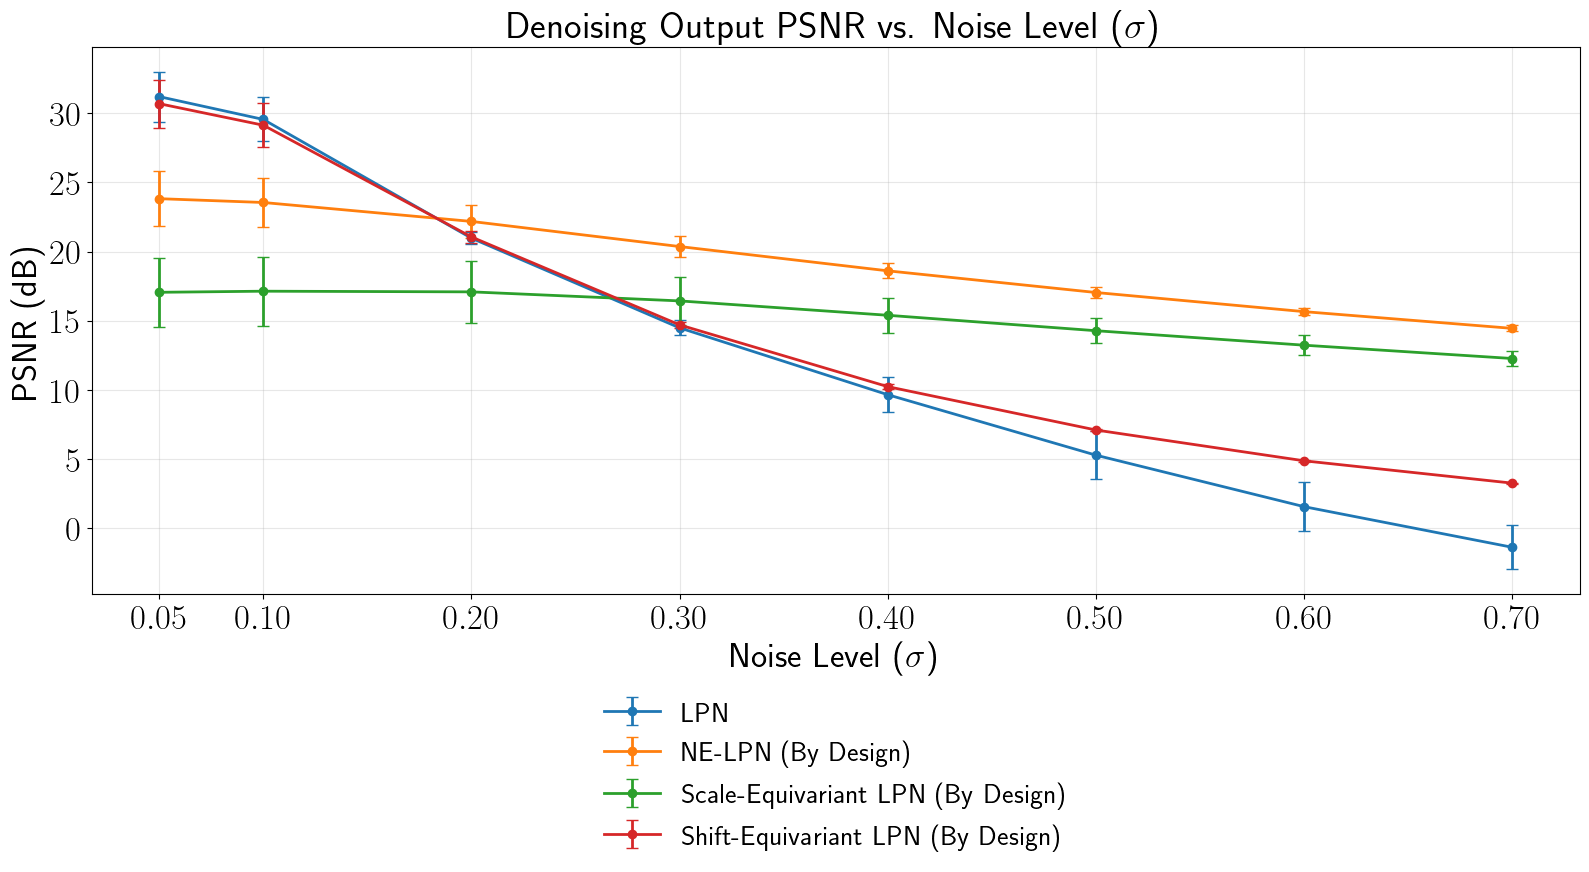

In [7]:
# plot psnr with the error bars

plt.figure(figsize=(16, 8))
for s in series:
    x = s["noise_levels"]
    y = s["psnr"]
    yerr = s["sd_psnr"]
    if yerr is not None:
        plt.errorbar(x, y, yerr=yerr, linewidth=2, marker='o', capsize=4, label=s["model_name"])
    else:
        plt.plot(x, y, linewidth=2, marker='o', label=s["model_name"])

plt.xlabel(r'Noise Level ($\sigma$)', fontsize=25)
plt.ylabel('PSNR (dB)', fontsize=25)
plt.title(r'Denoising Output PSNR vs. Noise Level ($\sigma$)', fontsize=27, fontweight='bold')
plt.xticks(series[0]["noise_levels"], fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=20, frameon=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig(save_dir + '/denoising_psnr_vs_noise_level.pdf', bbox_inches='tight')
plt.show()